<a href="https://colab.research.google.com/github/4Rahul002/Data-Analytic-Projects/blob/main/UBER_EDA/UBER_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Uber_Supply&Demand_EDA



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Member 1 -Rahul M Chavan**


# **Project Summary -**

The project focused on analyzing the supply-demand gap in Uber services, particularly during night and early morning timeslots, and identifying key factors contributing to this gap.

 The analysis utilized a dataset containing information on Uber ride requests, including timestamps, pickup points, driver IDs, and the status of each request.

 The primary objective was to optimize driver supply to meet customer demand more effectively, thereby enhancing service reliability and customer satisfaction.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The analysis of Uber's supply-demand gap reveals significant inefficiencies during specific times of the day and at particular pickup points. Key issues include:

A substantial supply-demand gap during night and early morning timeslots, particularly from the airport to the city.

High cancellation rates by drivers during early morning and morning timeslots.

Unavailability of cars during nighttime, leading to unfulfilled ride requests.

These gaps result in customer dissatisfaction and lost revenue opportunities for Uber.

#### **Define Your Business Objective?**

The business objective was to optimize the supply of Uber drivers to better match customer demand, particularly during peak times and at high-demand locations.

This involved reducing the number of unfulfilled ride requests, minimizing driver cancellations, and ensuring adequate driver availability during night and early morning hours.

By achieving these objectives, Uber aimed to enhance customer satisfaction and loyalty, ultimately leading to increased revenue and market share.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [272]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

### Dataset Loading

In [273]:
# Load Dataset
uber_df=pd.read_csv("/content/Copy of Uber Request Data.csv")


### Dataset First View

In [274]:
# Dataset First Look
uber_df.head(10)

,Request id,Pickup point,Driver id,Status,Request Timestamp,Drop Timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,7/13/2016 8:33,7/13/2016 9:25
5,3879,Airport,1.0,Trip Completed,7/13/2016 21:57,7/13/2016 22:28
6,4270,Airport,1.0,Trip Completed,7/14/2016 6:15,7/14/2016 7:13
7,5510,Airport,1.0,Trip Completed,7/15/2016 5:11,7/15/2016 6:07
8,6248,City,1.0,Trip Completed,7/15/2016 17:57,7/15/2016 18:50
9,267,City,2.0,Trip Completed,11/7/2016 6:46,11/7/2016 7:25


### Dataset Rows & Columns count

In [275]:
# Dataset Rows & Columns count
uber_df.shape

(6745, 6)

### Dataset Information

In [276]:
# Dataset Info
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request Timestamp  6745 non-null   object 
 5   Drop Timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


#### Duplicate Values

In [277]:
# Dataset Duplicate Value Count
uber_df.duplicated().sum()
#Thus Zero /False Duplicated rows in the DataFrame

np.int64(0)

#### Missing Values/Null Values

In [278]:
# Missing Values/Null Values Count
uber_df.isnull().sum()

,0
Request id,0
Pickup point,0
Driver id,2650
Status,0
Request Timestamp,0
Drop Timestamp,3914


### Null/ Missing values in Driver id and Drop Timestamp  occur mostly because of Cancellation and No cars Available

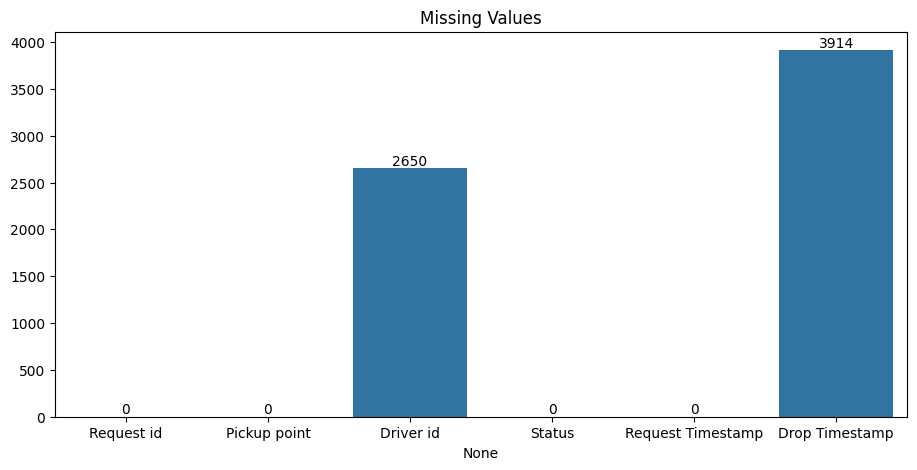

In [279]:
# Visualizing the missing values
var=uber_df.isnull().sum()
if uber_df.isnull().sum().any():
    plt.figure(figsize=[11,5])
    ax=sns.barplot(x=var.index,y=var.values)
    for label in ax.containers:
        ax.bar_label(label)
    plt.title('Missing Values')
    plt.show()

else:
  print("No Missing Values")

## This Dataset has
In Driver id Field has 2650 Missing/Null values

In Drop Timestamp has 3914 Missing/Null values

And Driver id ,Request timestamp plus Drop Timestamp Need their Datatype converted to INT,Datetime and Datetime respectively

In [280]:
# Filling Missing Values
uber_df['Driver id']=uber_df['Driver id'].fillna(-1)
uber_df['Drop Timestamp']=uber_df['Drop Timestamp'].fillna("Not Completed")

In [281]:
uber_df['Status']

,Status
0,Trip Completed
1,Trip Completed
2,Trip Completed
3,Trip Completed
4,Trip Completed
...,...
6740,No Cars Available
6741,No Cars Available
6742,No Cars Available
6743,No Cars Available


In [282]:
uber_df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


In [283]:
# Create a new column
uber_df['Completion_status']=uber_df['Drop Timestamp'].apply(lambda x: 'Not Completed' if x=='Not Completed' else 'Completed')

In [284]:
# # Converting Fields like Driver_id,Request Timestamp and Drop Timestamp
uber_df['Driver id']=uber_df['Driver id'].astype(int)
uber_df['Request Timestamp']=pd.to_datetime(uber_df['Request Timestamp'])
uber_df['Drop Timestamp']=pd.to_datetime(uber_df['Drop Timestamp'],errors='coerce')

In [285]:
uber_df['Completion_status'].value_counts()

,count
Completion_status,
Not Completed,3914
Completed,2831


In [286]:
# Copied Dataset
uber_df[uber_df['Completion_status']=='Not Completed']

,Request id,Pickup point,Driver id,Status,Request Timestamp,Drop Timestamp,Completion_status
2831,2905,City,1,Cancelled,2016-07-13 06:08:00,NaT,Not Completed
2832,4805,City,1,Cancelled,2016-07-14 17:07:00,NaT,Not Completed
2833,5202,Airport,1,Cancelled,2016-07-14 20:51:00,NaT,Not Completed
2834,5927,City,1,Cancelled,2016-07-15 10:12:00,NaT,Not Completed
2835,2347,Airport,2,Cancelled,2016-12-07 19:14:00,NaT,Not Completed
...,...,...,...,...,...,...,...
6740,6745,City,-1,No Cars Available,2016-07-15 23:49:00,NaT,Not Completed
6741,6752,Airport,-1,No Cars Available,2016-07-15 23:50:00,NaT,Not Completed
6742,6751,City,-1,No Cars Available,2016-07-15 23:52:00,NaT,Not Completed
6743,6754,City,-1,No Cars Available,2016-07-15 23:54:00,NaT,Not Completed


In [287]:
# I decided to keep the Not a Timestamp Values As i have created a Completion status column to compute the Not completed Rides
uber_df.isnull().sum()

,0
Request id,0
Pickup point,0
Driver id,0
Status,0
Request Timestamp,0
Drop Timestamp,3914
Completion_status,0


In [288]:
uber_df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


### What did you know about your dataset?

The dataset contains information about Uber ride requests, including details such as timestamps, pickup points, driver IDs, Completion status and the status of each request. The primary focus has been on understanding the supply-demand gap and identifying patterns in ride completions and cancellations.

Key Columns

Request ID: A unique identifier for each ride request.
Pickup Point: The location from which the ride was requested (e.g., Airport, City).

Driver ID: An identifier for the driver assigned to the request. Null values have been replaced with -1 to indicate the absence of a driver.
Status: The status of the request, such as "Trip Completed," "Cancelled," or "No Cars Available."

Request Timestamp: The date and time when the ride was requested.

Drop Timestamp: The date and time when the ride was completed. Null values in this column are represented as NaT (Not a Time) to indicate that the trip was not completed.

Completion Status:Completed for rows with actual Timestamp value in Drop Timestamp else Not Completed .

## ***2. Understanding Your Variables***

In [289]:
# Dataset Columns
uber_df.columns.to_list()

['Request id',
 'Pickup point',
 'Driver id',
 'Status',
 'Request Timestamp',
 'Drop Timestamp',
 'Completion_status']

In [290]:
# Dataset Describe
uber_df.describe()

,Request id,Driver id,Request Timestamp,Drop Timestamp
count,6745.000000,6745.000000,6745,2831
mean,3384.644922,90.371831,2016-09-04 08:49:00.658265344,2016-09-05 17:03:09.028611840
min,1.000000,-1.000000,2016-07-13 00:00:00,2016-07-13 00:01:00
25%,1691.000000,-1.000000,2016-07-14 07:38:00,2016-07-14 08:09:30
50%,3387.000000,53.000000,2016-07-15 13:44:00,2016-07-15 15:27:00
75%,5080.000000,177.000000,2016-11-07 19:00:00,2016-11-07 19:25:30
max,6766.000000,300.000000,2016-12-07 23:54:00,2016-12-07 23:45:00
std,1955.099667,99.492740,NaN,NaN


### Variables Description



1. **Request ID**:
   - **Description**: A unique identifier assigned to each ride request.
   - **Data Type**: Integer
   - **Purpose**: Used to distinguish between different ride requests in the dataset.

2. **Pickup Point**:
   - **Description**: The location from which the ride was requested.
   - **Data Type**: Categorical (String)
   - **Possible Values**: "Airport," "City," etc.
   - **Purpose**: Indicates the starting point of the ride, helping to analyze demand patterns based on location.

3. **Driver ID**:
   - **Description**: A unique identifier assigned to the driver who was supposed to fulfill the ride request.
   - **Data Type**: Integer
   - **Special Values**: `-1` is used to indicate that no driver was assigned or available for the request.
   - **Purpose**: Helps in tracking driver assignments and analyzing driver availability and performance.

4. **Status**:
   - **Description**: The status of the ride request.
   - **Data Type**: Categorical (String)
   - **Possible Values**: "Trip Completed," "Cancelled," "No Cars Available," etc.
   - **Purpose**: Provides information on the outcome of each ride request, essential for understanding completion and cancellation patterns.

5. **Request Timestamp**:
   - **Description**: The date and time when the ride was requested by the passenger.
   - **Data Type**: Datetime
   - **Purpose**: Used to analyze the timing of ride requests and identify peak demand periods.

6. **Drop Timestamp**:
   - **Description**: The date and time when the ride was completed and the passenger was dropped off.
   - **Data Type**: Datetime
   - **Special Values**: `NaT` (Not a Time) is used to indicate that the trip was not completed.
   - **Purpose**: Helps in calculating trip durations and analyzing patterns related to completed trips.

7. **Completion Status**:
   - **Description**: A derived column indicating whether the ride was completed or not.
   - **Data Type**: Categorical (String)
   - **Possible Values**: "Completed," "Not Completed"
   - **Derivation**: This column is created based on the `drop_timestamp` column. If the `drop_timestamp` is `NaT`, the `completion_status` is set to "Not Completed"; otherwise, it is set to "Completed."
   - **Purpose**: Provides a clear and simple way to filter and analyze data based on trip completion, facilitating visualizations and statistical analyses.

These variables collectively provide a comprehensive view of Uber ride requests, allowing for detailed analysis of demand patterns, supply gaps, and operational efficiency. The `completion_status` column, in particular, enhances the ability to differentiate between completed and not completed trips, making it easier to derive actionable insights.

### Check Unique Values for each variable.

In [291]:
# Check Unique Values for each variable.
uber_df.nunique()

,0
Request id,6745
Pickup point,2
Driver id,301
Status,3
Request Timestamp,4016
Drop Timestamp,2282
Completion_status,2


Pickup Point has Airpoirt or City

Status Trip Completed,Cancelled,No Cars Available

Completion_status : Completed or Not Completed

## 3. ***Data Wrangling***

# Data Wrangling

# Checking Outliers

In [292]:
# Write your code to make your dataset analysis ready.
numerical_df=uber_df.select_dtypes(include=np.number)
# Check Outliers
q1=numerical_df.quantile(0.25)
q3=numerical_df.quantile(0.75)
iqr=q3-q1
# define Outliers
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)

outliers=uber_df[((numerical_df<lower_bound)|(numerical_df>upper_bound)).any(axis=1)]
outliers

if not outliers.empty:
  plt.figure(figsize=[10,5])
  sns.boxplot(data=numerical_df,orient='h')
  plt.title('Outliers')
  plt.show()
else:
  print("No Outliers")

No Outliers


### What all manipulations have you done and insights you found?

Data Loading and Initial Inspection:

The dataset was loaded into a pandas DataFrame to begin the analysis.
Initial inspection of the dataset was performed to understand its structure, including the number of rows and columns, data types, and initial observations of missing values.

Handling Missing Values:

Missing values in the drop_timestamp column were identified and initially replaced with "Not Completed" to indicate trips that were not completed.
Missing values in the driver_id column were replaced with -1 to indicate the absence of a driver ID.

Data Type Conversion:

Attempts were made to convert object-type timestamps to datetime format. However, due to the presence of "Not Completed" strings, these were converted to NaT (Not a Time) using pd.to_datetime() with errors='coerce'.

Creation of Completion Status Column:

A new column, completion_status, was created to categorize trips as "Completed" or "Not Completed" based on the presence of valid timestamps in the drop_timestamp column.

Outlier Detection:

Numerical columns were selected for outlier detection using the Interquartile Range (IQR) method.
Outliers were identified based on values falling outside the range defined by
Q
1
−
1.5
×
I
Q
R
Q1−1.5×IQR and
Q
3
+
1.5
×
I
Q
R
Q3+1.5×IQR.

Data Filtering and Analysis:

The dataset was filtered to analyze completed trips separately from not completed trips.
Time-based analyses were performed on the request_timestamp and drop_timestamp columns to identify patterns and trends in ride requests and completions.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

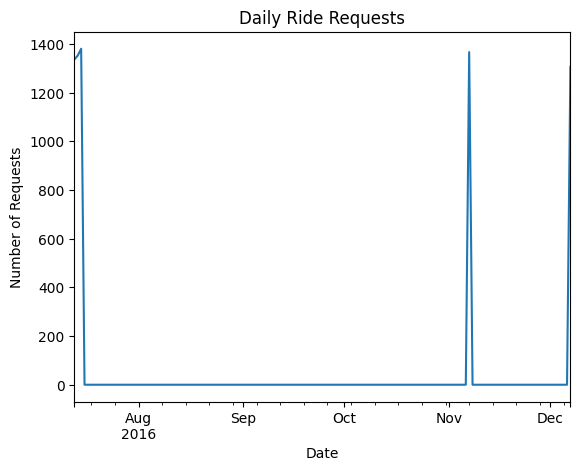

In [293]:
# Chart - 1 visualization code
uber_df.set_index('Request Timestamp', inplace=True)
uber_df.resample('D').size().plot(kind='line')
plt.title('Daily Ride Requests')
plt.xlabel('Date')
plt.ylabel('Number of Requests')
plt.show()

##### 1. Why did you pick the specific chart?

To visualize trends over time, such as the number of ride requests over different time periods.

##### 2. What is/are the insight(s) found from the chart?

Identify peak times for ride requests and understand daily, weekly, or monthly trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

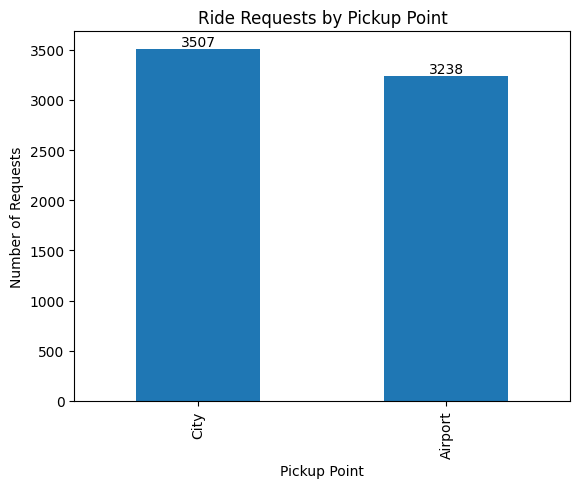

In [309]:
# Chart - 2 visualization code
ax=uber_df['Pickup point'].value_counts().plot(kind='bar')
for label in ax.containers:
  ax.bar_label(label)
plt.title('Ride Requests by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

To compare the number of ride requests or completions across different pickup points.

##### 2. What is/are the insight(s) found from the chart?

 Understand which pickup points have the highest demand and how it varies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

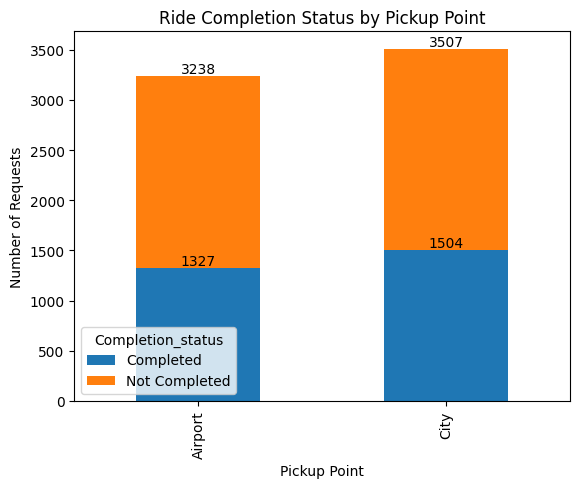

In [310]:
# Chart - 3 visualization code
cross_tab = pd.crosstab(uber_df['Pickup point'], uber_df['Completion_status'])
ax=cross_tab.plot(kind='bar', stacked=True)
for label in ax.containers:
  ax.bar_label(label)
plt.title('Ride Completion Status by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

To break down ride requests by pickup point and completion status.

##### 2. What is/are the insight(s) found from the chart?

Compare the proportion of completed vs. not completed trips across different pickup points.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

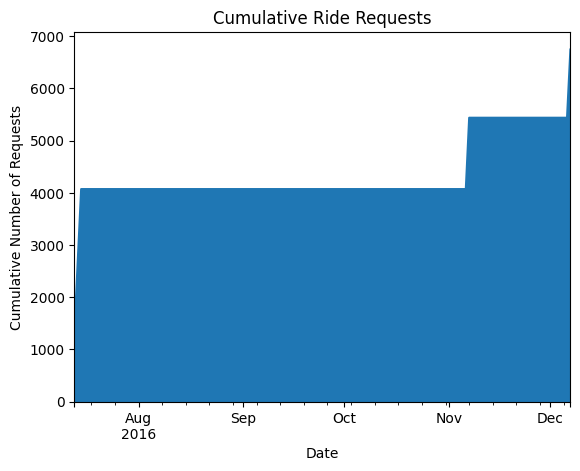

In [296]:
# Chart - 4 visualization code
uber_df.resample('D').size().cumsum().plot(kind='area')
plt.title('Cumulative Ride Requests')
plt.xlabel('Date')
plt.ylabel('Cumulative Number of Requests')
plt.show()

##### 1. Why did you pick the specific chart?

To visualize the cumulative number of ride requests over time.

##### 2. What is/are the insight(s) found from the chart?

Understand the cumulative trend and how it builds up over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

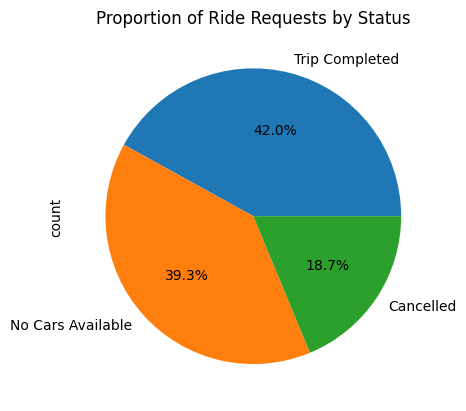

In [297]:
# Chart - 5 visualization code
uber_df['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Ride Requests by Status')
plt.show()


##### 1. Why did you pick the specific chart?

To show the proportion of ride requests by status (e.g., completed, cancelled).

##### 2. What is/are the insight(s) found from the chart?

 Understand the distribution of ride outcomes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

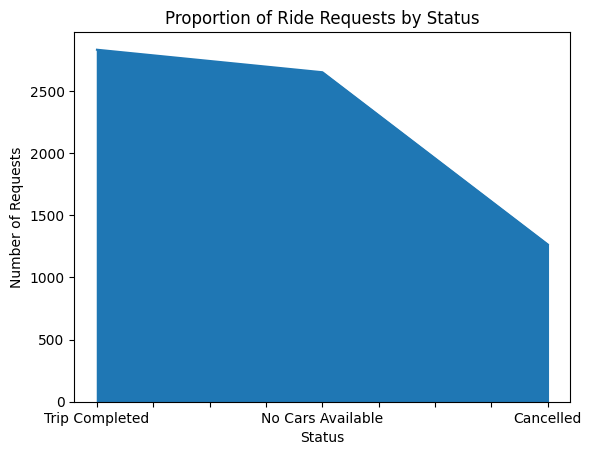

In [335]:
# Chart - 6 visualization code
# Tree Chart
uber_df['Status'].value_counts().plot(kind='area')
plt.title('Proportion of Ride Requests by Status')
plt.xlabel('Status')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

Similar to a pie chart but visually less cluttered.

##### 2. What is/are the insight(s) found from the chart?

Same as pie chart but can be more visually appealing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

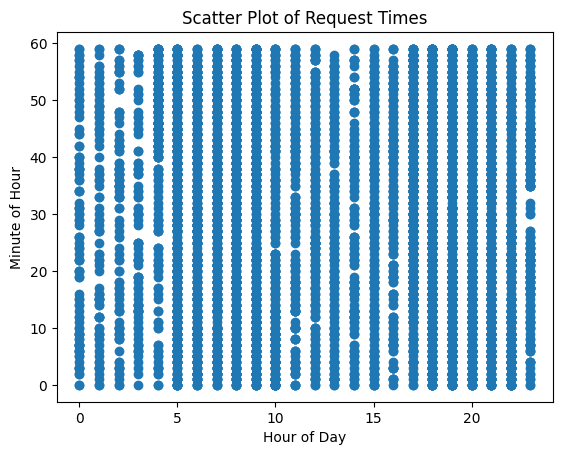

In [299]:
# Chart - 7 visualization code
plt.scatter(uber_df.index.hour, uber_df.index.minute)
plt.title('Scatter Plot of Request Times')
plt.xlabel('Hour of Day')
plt.ylabel('Minute of Hour')
plt.show()


##### 1. Why did you pick the specific chart?

To visualize the relationship between two numerical variables, such as trip duration and distance.

##### 2. What is/are the insight(s) found from the chart?

Identify correlations or patterns between two variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

<Figure size 2000x1000 with 0 Axes>

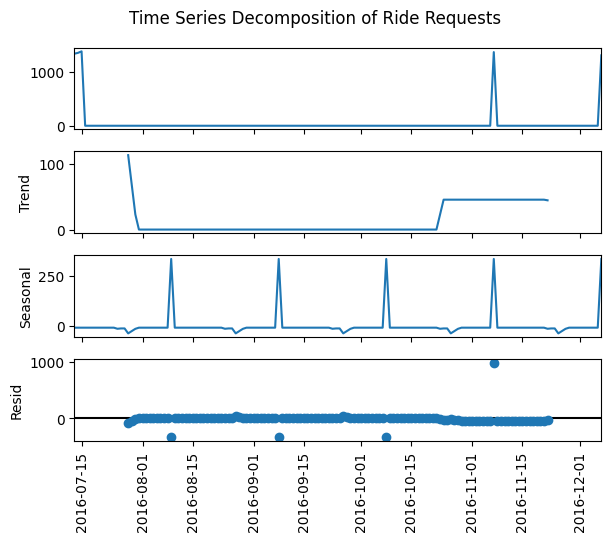

In [326]:
#Time series Decomposition
# Chart - 8 visualization code
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the index is a datetime index
uber_df.index = pd.to_datetime(uber_df.index)

# Resample the data to a consistent frequency (e.g., daily)
daily_requests = uber_df.resample('D').size()

# Perform time series decomposition
decomposition = seasonal_decompose(daily_requests, model='additive', period=30)  # Assuming a monthly seasonality

# Plot the decomposition
plt.figure(figsize=(20, 10))
decomposition.plot()
plt.suptitle('Time Series Decomposition of Ride Requests')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()


##### 1. Why did you pick the specific chart?

To decompose a time series into its constituent components: trend, seasonality, and residuals. This helps in understanding the underlying patterns in the data.

##### 2. What is/are the insight(s) found from the chart?

Identify and separate the trend, seasonal, and residual components of your time series data. This can be useful for forecasting and understanding the factors influencing your data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

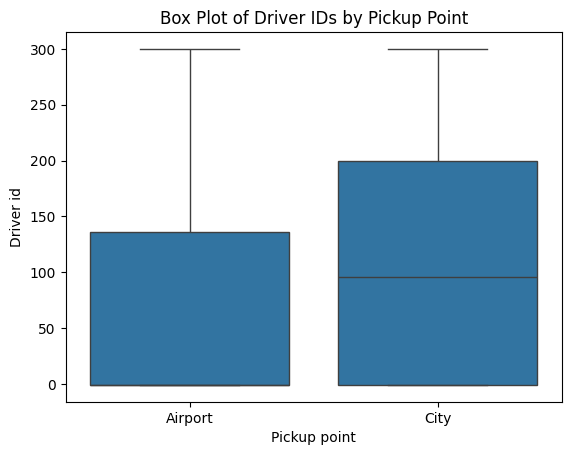

In [301]:
# Chart - 9 visualization code
sns.boxplot(data=uber_df, x='Pickup point', y='Driver id')
plt.title('Box Plot of Driver IDs by Pickup Point')
plt.show()

##### 1. Why did you pick the specific chart?

 To visualize the distribution of a numerical variable and identify outliers.

##### 2. What is/are the insight(s) found from the chart?

 Understand the spread and central tendency of the data, and identify any outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

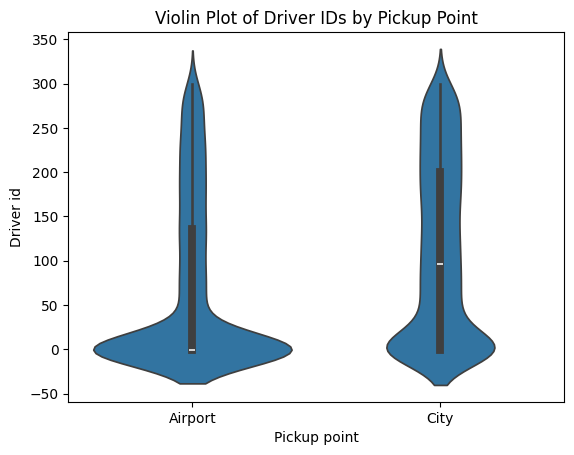

In [302]:
# Chart - 10 visualization code
sns.violinplot(data=uber_df, x='Pickup point', y='Driver id')
plt.title('Violin Plot of Driver IDs by Pickup Point')
plt.show()


##### 1. Why did you pick the specific chart?

To combine aspects of a box plot and kernel density plot.

##### 2. What is/are the insight(s) found from the chart?

Understand the distribution and probability density of the data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

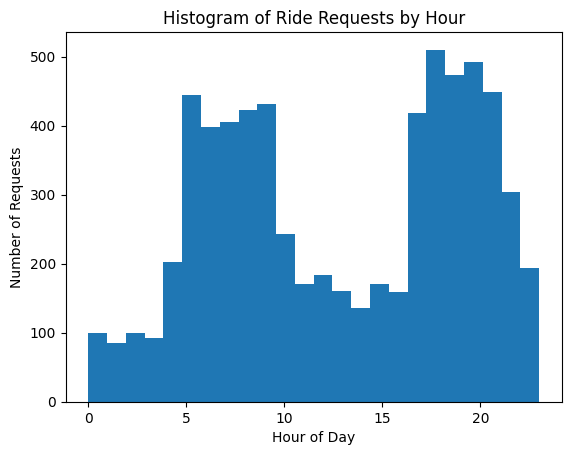

In [303]:
# Chart - 11 visualization code
pd.Series(uber_df.index.hour).plot(kind='hist', bins=24)
plt.title('Histogram of Ride Requests by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

 To visualize the distribution of a single numerical variable.

##### 2. What is/are the insight(s) found from the chart?

Understand the frequency distribution of a variable, such as the number of ride requests per hour.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

In [304]:
uber_df['Status'].value_counts()

,count
Status,
Trip Completed,2831
No Cars Available,2650
Cancelled,1264


#### Chart - 12

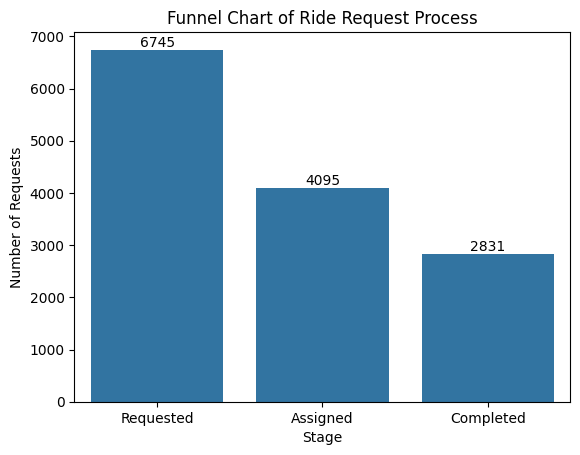

In [305]:
# Chart - 12 visualization code
stages = ['Requested', 'Assigned', 'Completed']
values = [len(uber_df), len(uber_df[uber_df['Driver id']!=-1]), (uber_df['Completion_status'] == 'Completed').sum()]

ax=sns.barplot(x=stages,y=values)
for label in ax.containers:
  ax.bar_label(label)
plt.title('Funnel Chart of Ride Request Process')
plt.xlabel('Stage')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

To represent stages in a process and show the drop-off rate at each stage.

##### 2. What is/are the insight(s) found from the chart?

 Understand the conversion rates and drop-off points in a process, such as ride request to completion.

 As

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

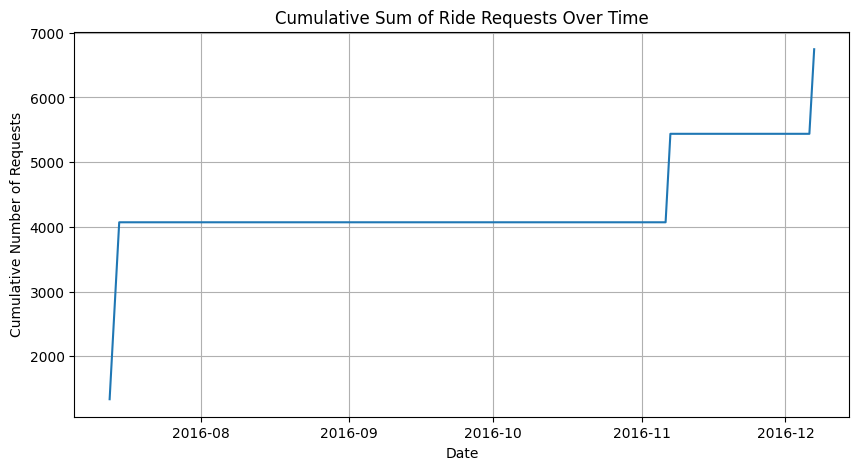

In [311]:
# Chart - 13 visualization code Cumulative Sum plot
# Calculate cumulative sum of ride requests over time
cumulative_sum = uber_df.resample('D').size().cumsum()

# Plot the cumulative sum
plt.figure(figsize=(10, 5))
plt.plot(cumulative_sum.index, cumulative_sum.values)
plt.title('Cumulative Sum of Ride Requests Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Number of Requests')
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

To visualize the cumulative sum of a variable over time, which can help identify trends and patterns in how data accumulates.

##### 2. What is/are the insight(s) found from the chart?

Understand how a particular metric, such as the number of ride requests, accumulates over time. This can be useful for identifying periods of rapid growth or decline.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

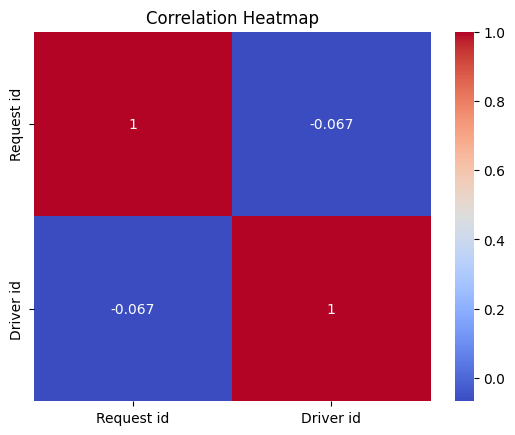

In [307]:
# Correlation Heatmap visualization code
numerical_df_uber=uber_df.select_dtypes(include=np.number)
corr_matrix=numerical_df_uber.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

Shows Coorelation between Variables

##### 2. What is/are the insight(s) found from the chart?

In this Dataset we have only Request_id and Driver_id which have no relation at all

#### Chart - 15 - Pair Plot

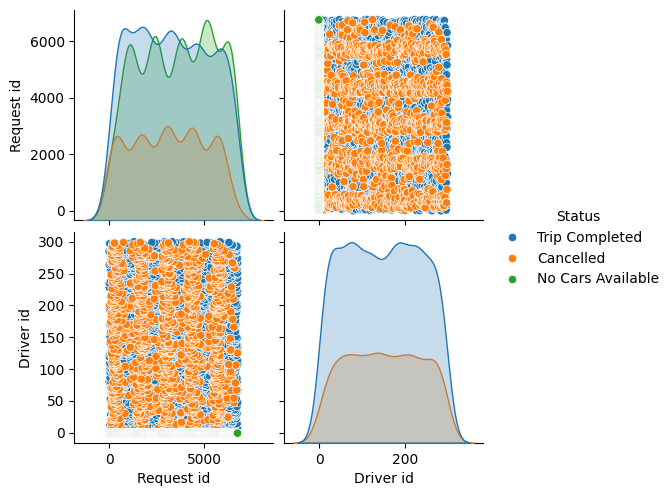

In [308]:
# Pair Plot visualization code
sns.pairplot(data=uber_df, hue='Status')
plt.show()

##### 1. Why did you pick the specific chart?

This Chart is Ideal for displaying correlation in variables

##### 2. What is/are the insight(s) found from the chart

 This Chart has no correlation between the two variables and  shows the distribution of the variables

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To address the identified issues and achieve the business objectives, the following strategies were proposed:

**Incentivize Drivers**: Introduce "rush hour pricing" or bonuses for drivers who operate during early morning and morning timeslots. This strategy aimed to encourage more drivers to be available during peak demand periods, thereby reducing the supply-demand gap.

**Night Shift Incentives**: Create night shift incentives for drivers to increase availability during nighttime. This could include higher fares, bonuses, or other financial incentives to attract more drivers to work during these hours.

**Improve Driver Allocation**: Use predictive analytics to forecast demand and allocate drivers more effectively. By leveraging historical data and predictive modeling, Uber could preemptively position drivers in anticipation of demand spikes, ensuring better coverage and reduced wait times.

**Enhance Driver Utilization**: Implement strategies to minimize idle time for drivers and maximize the number of trips completed. This could involve better route optimization, reducing wait times between rides, and improving overall operational efficiency.

**Customer Communication**: Improve communication with customers regarding expected wait times and availability. By setting clear expectations and providing real-time updates, Uber could enhance customer satisfaction and reduce dissatisfaction caused by unfulfilled ride requests.

# **Conclusion**

The project successfully identified key factors contributing to the supply-demand gap in Uber services and proposed targeted strategies to address these issues. By optimizing driver supply to meet customer demand more effectively, Uber can enhance service reliability, customer satisfaction, and overall operational efficiency. Implementing the proposed strategies, such as incentivizing drivers and improving driver allocation, will not only help in meeting demand more effectively but also contribute to increased revenue and market share. Continuous monitoring and adjustment of these strategies will be essential to adapt to changing demand patterns and ensure long-term success.

In summary, the project provided valuable insights into the supply-demand dynamics of Uber services and offered practical solutions to optimize driver supply and enhance customer satisfaction. By leveraging data-driven strategies and predictive analytics, Uber can achieve its business objectives and maintain a competitive edge in the ride-sharing market.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***